# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
!pip install mtcnn tensorflow opencv-python matplotlib tqdm


  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 986.0 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.7 MB/s eta 0:00:0000:0100:09m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 2.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 1.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 2.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 1.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 924.7 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 1.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 748.2 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 782.3 kB/s 

In [2]:
import os
import cv2
import numpy as np
from mtcnn import MTCNN
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models

# EfficientNetB3
from tensorflow.keras.applications.efficientnet import EfficientNetB3, preprocess_input

DATASET_DIR = "kaggle-genki4k"
CROPPED_DIR = "cropped_effnetb3"
IMG_SIZE = (300, 300)
BATCH_SIZE = 16


In [4]:
RAW_SMILE = os.path.join(DATASET_DIR, "smile")
RAW_NONE  = os.path.join(DATASET_DIR, "non_smile")


In [5]:
def align_face(img, left_eye, right_eye):

    lx, ly = int(round(left_eye[0])), int(round(left_eye[1]))
    rx, ry = int(round(right_eye[0])), int(round(right_eye[1]))
    eye_center = ((lx + rx) // 2, (ly + ry) // 2)

    dy = ry - ly
    dx = rx - lx
    angle = np.degrees(np.arctan2(dy, dx))

    M = cv2.getRotationMatrix2D(eye_center, angle, 1.0)
    h, w = img.shape[:2]
    aligned = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC)
    return aligned


In [6]:
detector = MTCNN()

def detect_align_crop_safe(img_rgb, pad_w_ratio=0.18, pad_h_ratio=0.25):

    dets = detector.detect_faces(img_rgb)
    if not dets:
        return None

    det = max(dets, key=lambda x: x['box'][2] * x['box'][3])
    x, y, w, h = det['box']
    x, y, w, h = int(x), int(y), int(w), int(h)

    kp = det.get('keypoints', {})
    if 'left_eye' in kp and 'right_eye' in kp:
        try:
            aligned = align_face(img_rgb, kp['left_eye'], kp['right_eye'])
        except Exception as e:
            aligned = img_rgb
    else:
        aligned = img_rgb

    pad_w = int(w * pad_w_ratio)
    pad_h = int(h * pad_h_ratio)
    x1 = max(0, x - pad_w)
    y1 = max(0, y - pad_h)
    x2 = min(aligned.shape[1], x + w + pad_w)
    y2 = min(aligned.shape[0], y + h + pad_h)

    if x2 <= x1 or y2 <= y1:
        return None

    face = aligned[y1:y2, x1:x2]
    return face


In [7]:
def process_and_save(in_dir, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    count = 0
    skipped = 0
    for fname in tqdm(os.listdir(in_dir)):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        p = os.path.join(in_dir, fname)
        img_bgr = cv2.imread(p)
        if img_bgr is None:
            skipped += 1
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        face = detect_align_crop_safe(img_rgb)
        if face is None:
            skipped += 1
            continue
        out_path = os.path.join(out_dir, fname)
        cv2.imwrite(out_path, cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
        count += 1
    print(f"Saved {count} crops, skipped {skipped} (from {in_dir})")

process_and_save(RAW_SMILE, os.path.join(CROPPED_DIR, "smile"))
process_and_save(RAW_NONE, os.path.join(CROPPED_DIR, "non_smile"))


100%|██████████| 2162/2162 [02:34<00:00, 14.02it/s]


Saved 2160 crops, skipped 2 (from kaggle-genki4k/smile)


100%|██████████| 1838/1838 [02:08<00:00, 14.34it/s]

Saved 1826 crops, skipped 12 (from kaggle-genki4k/non_smile)


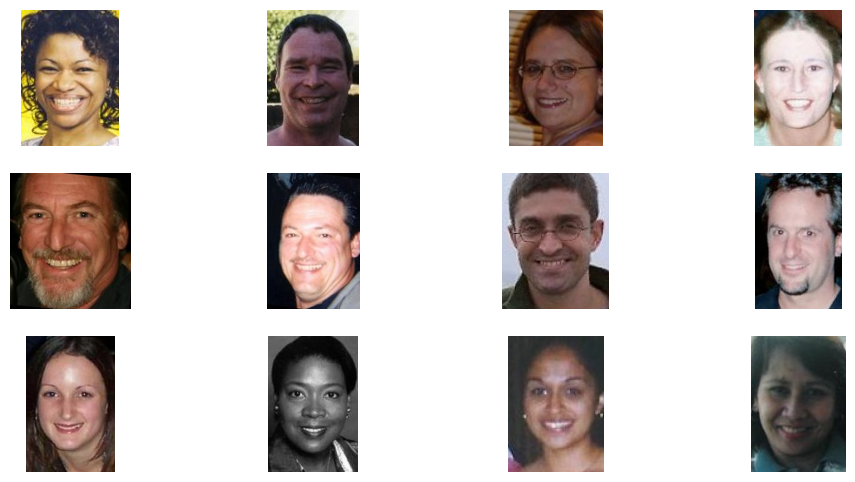

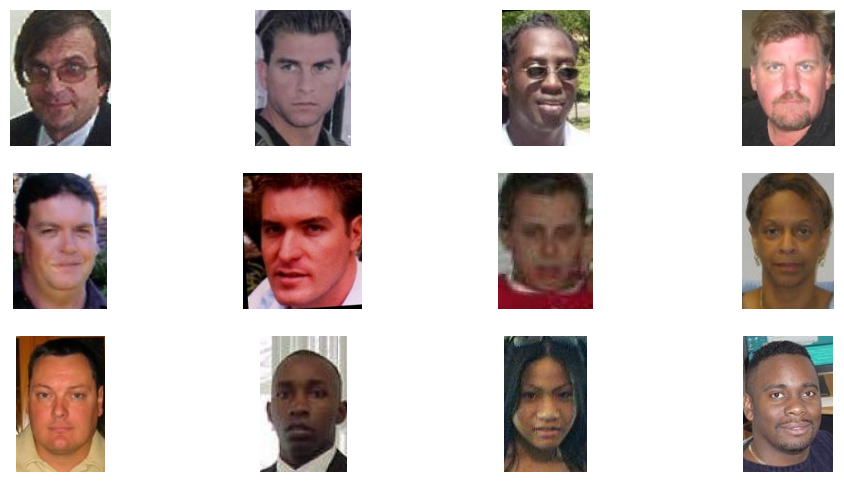

In [8]:
import matplotlib.pyplot as plt
def show_samples(folder, n=12):
    files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg",".png",".jpeg"))][:n]
    plt.figure(figsize=(12,6))
    for i,f in enumerate(files):
        img = cv2.imread(os.path.join(folder,f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(3, 4, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()

show_samples(os.path.join(CROPPED_DIR, "smile"))
show_samples(os.path.join(CROPPED_DIR, "non_smile"))


In [10]:
FINAL_SIZE = IMG_SIZE

def resize_all(root_dir):
    removed = 0
    for lab in ["smile","non_smile"]:
        folder = os.path.join(root_dir, lab)
        for fname in list(os.listdir(folder)):
            path = os.path.join(folder, fname)
            try:
                img = cv2.imread(path)
                if img is None or img.size==0:
                    os.remove(path); removed+=1; continue
                img = cv2.resize(img, FINAL_SIZE, interpolation=cv2.INTER_AREA)
                cv2.imwrite(path, img)
            except Exception as e:
                try:
                    os.remove(path)
                    removed += 1
                except:
                    pass
    print("Removed problematic files:", removed)

resize_all(CROPPED_DIR)
print("Resize done.")


Removed problematic files: 0
Resize done.


In [11]:
data = []
for lab in ["smile","non_smile"]:
    folder = os.path.join(CROPPED_DIR, lab)
    for fname in os.listdir(folder):
        if not fname.lower().endswith((".jpg",".jpeg",".png")):
            continue
        data.append({"path": os.path.join(folder, fname), "label": 1 if lab=="smile" else 0})

df = pd.DataFrame(data)
print("Total images:", len(df))
print(df['label'].value_counts())
df.head()


Total images: 3986
label
1    2160
0    1826
Name: count, dtype: int64


,path,label
0,cropped_effnetb3/smile/file1358.jpg,1
1,cropped_effnetb3/smile/file0025.jpg,1
2,cropped_effnetb3/smile/file1693.jpg,1
3,cropped_effnetb3/smile/file1806.jpg,1
4,cropped_effnetb3/smile/file0428.jpg,1


In [12]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

print("Train/Val/Test sizes:", len(train_df), len(val_df), len(test_df))


Train/Val/Test sizes: 2790 598 598


In [13]:
from sklearn.utils import class_weight
import numpy as np

classes = np.unique(train_df['label'])
cw = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=train_df['label'])
class_weights = {int(classes[i]): float(cw[i]) for i in range(len(classes))}
print("class_weights:", class_weights)


class_weights: {0: 1.091549295774648, 1: 0.9226190476190477}


In [14]:
# augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.08),
    layers.RandomTranslation(0.05, 0.05)
])

def load_and_preprocess(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)
    if augment:
        img = data_augmentation(img)
    img = preprocess_input(img)
    return img, label

def make_ds(df, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((df['path'].values, df['label'].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(lambda p,l: load_and_preprocess(p, l, augment=augment))
    ds = ds.batch(BATCH_SIZE)
    return ds

train_ds = make_ds(train_df, augment=True, shuffle=True)
val_ds = make_ds(val_df, augment=False, shuffle=False)
test_ds = make_ds(test_df, augment=False, shuffle=False)


In [15]:
base_model = EfficientNetB3(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)



43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,570,992 (44.14 MB)

 Trainable params: 787,457 (3.00 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [16]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_effb3_head.h5", monitor='val_auc', mode='max', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=6, mode='max', restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, mode='max', min_lr=1e-7)
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.6351 - auc: 0.6994 - loss: 0.6468

175/175 ━━━━━━━━━━━━━━━━━━━━ 172s 937ms/step - accuracy: 0.6882 - auc: 0.7552 - loss: 0.5975 - val_accuracy: 0.7308 - val_auc: 0.8010 - val_loss: 0.5416 - learning_rate: 0.0010
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.7415 - auc: 0.8200 - loss: 0.5199

175/175 ━━━━━━━━━━━━━━━━━━━━ 163s 930ms/step - accuracy: 0.7373 - auc: 0.8123 - loss: 0.5314 - val_accuracy: 0.7341 - val_auc: 0.8215 - val_loss: 0.5166 - learning_rate: 0.0010
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.7528 - auc: 0.8330 - loss: 0.5065

175/175 ━━━━━━━━━━━━━━━━━━━━ 173s 984ms/step - accuracy: 0.7434 - auc: 0.8206 - loss: 0.5202 - val_accuracy: 0.7375 - val_auc: 0.8263 - val_loss: 0.5320 - learning_rate: 0.0010
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - accuracy: 0.7592 - auc: 0.8397 - loss: 0.4965

175/175 ━━━━━━━━━━━━━━━━━━━━ 169s 963ms/step - accuracy: 0.7541 - auc: 0.8353 - loss: 0.5033 - val_accuracy: 0.7341 - val_auc: 0.8348 - val_loss: 0.5345 - learning_rate: 0.0010
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 163s 927ms/step - accuracy: 0.7530 - auc: 0.8414 - loss: 0.4897 - val_accuracy: 0.7458 - val_auc: 0.8334 - val_loss: 0.5069 - learning_rate: 0.0010
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.7647 - auc: 0.8502 - loss: 0.4767

175/175 ━━━━━━━━━━━━━━━━━━━━ 164s 937ms/step - accuracy: 0.7602 - auc: 0.8447 - loss: 0.4869 - val_accuracy: 0.7592 - val_auc: 0.8521 - val_loss: 0.4818 - learning_rate: 0.0010
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 164s 932ms/step - accuracy: 0.7681 - auc: 0.8530 - loss: 0.4747 - val_accuracy: 0.7592 - val_auc: 0.8440 - val_loss: 0.4870 - learning_rate: 0.0010
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.7697 - auc: 0.8491 - loss: 0.4788

175/175 ━━━━━━━━━━━━━━━━━━━━ 164s 937ms/step - accuracy: 0.7771 - auc: 0.8567 - loss: 0.4698 - val_accuracy: 0.7642 - val_auc: 0.8577 - val_loss: 0.4793 - learning_rate: 0.0010
Epoch 9/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.7670 - auc: 0.8570 - loss: 0.4655 - val_accuracy: 0.7508 - val_auc: 0.8523 - val_loss: 0.5071 - learning_rate: 0.0010
Epoch 10/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.7881 - auc: 0.8708 - loss: 0.4526

175/175 ━━━━━━━━━━━━━━━━━━━━ 173s 988ms/step - accuracy: 0.7756 - auc: 0.8649 - loss: 0.4576 - val_accuracy: 0.7726 - val_auc: 0.8605 - val_loss: 0.4652 - learning_rate: 0.0010
Epoch 11/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 164s 932ms/step - accuracy: 0.7896 - auc: 0.8710 - loss: 0.4485 - val_accuracy: 0.7776 - val_auc: 0.8489 - val_loss: 0.4934 - learning_rate: 0.0010
Epoch 12/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 165s 938ms/step - accuracy: 0.7882 - auc: 0.8715 - loss: 0.4495 - val_accuracy: 0.7676 - val_auc: 0.8519 - val_loss: 0.4902 - learning_rate: 0.0010
Epoch 13/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 165s 942ms/step - accuracy: 0.7961 - auc: 0.8802 - loss: 0.4329 - val_accuracy: 0.7776 - val_auc: 0.8548 - val_loss: 0.4808 - learning_rate: 0.0010
Epoch 14/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 166s 945ms/step - accuracy: 0.7971 - auc: 0.8828 - loss: 0.4311 - val_accuracy: 0.7659 - val_auc: 0.8551 - val_loss: 0.4854 - learning_rate: 5.0000e-04
Epoch 15/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - accura

175/175 ━━━━━━━━━━━━━━━━━━━━ 167s 951ms/step - accuracy: 0.7943 - auc: 0.8866 - loss: 0.4222 - val_accuracy: 0.7609 - val_auc: 0.8611 - val_loss: 0.4934 - learning_rate: 5.0000e-04
Epoch 16/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 164s 934ms/step - accuracy: 0.8039 - auc: 0.8875 - loss: 0.4195 - val_accuracy: 0.7776 - val_auc: 0.8549 - val_loss: 0.4809 - learning_rate: 5.0000e-04
Epoch 17/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.8219 - auc: 0.9015 - loss: 0.3982

175/175 ━━━━━━━━━━━━━━━━━━━━ 165s 939ms/step - accuracy: 0.8190 - auc: 0.8983 - loss: 0.4038 - val_accuracy: 0.7826 - val_auc: 0.8709 - val_loss: 0.4556 - learning_rate: 5.0000e-04
Epoch 18/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 163s 931ms/step - accuracy: 0.8158 - auc: 0.8987 - loss: 0.4015 - val_accuracy: 0.7826 - val_auc: 0.8677 - val_loss: 0.4528 - learning_rate: 5.0000e-04
Epoch 19/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 165s 938ms/step - accuracy: 0.8054 - auc: 0.8925 - loss: 0.4116 - val_accuracy: 0.7893 - val_auc: 0.8630 - val_loss: 0.4612 - learning_rate: 5.0000e-04
Epoch 20/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 165s 943ms/step - accuracy: 0.8251 - auc: 0.9009 - loss: 0.3983 - val_accuracy: 0.7910 - val_auc: 0.8708 - val_loss: 0.4523 - learning_rate: 5.0000e-04


In [17]:
base_model.trainable = True

freeze_until = len(base_model.layers) - 60
for i, layer in enumerate(base_model.layers):
    layer.trainable = True if i >= freeze_until else False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-6),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks_ft = [
    tf.keras.callbacks.ModelCheckpoint("best_effb3_ft.h5", monitor='val_auc', mode='max', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=6, mode='max', restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, mode='max', min_lr=1e-8)
]

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weights,
    callbacks=callbacks_ft
)


Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6408 - auc: 0.7283 - loss: 0.7460

175/175 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.6588 - auc: 0.7416 - loss: 0.7182 - val_accuracy: 0.7776 - val_auc: 0.8573 - val_loss: 0.5336 - learning_rate: 3.0000e-06
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6961 - auc: 0.7707 - loss: 0.6459

175/175 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.6971 - auc: 0.7750 - loss: 0.6382 - val_accuracy: 0.7759 - val_auc: 0.8609 - val_loss: 0.4981 - learning_rate: 3.0000e-06
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7175 - auc: 0.7951 - loss: 0.5966

175/175 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.7201 - auc: 0.7923 - loss: 0.6031 - val_accuracy: 0.7793 - val_auc: 0.8712 - val_loss: 0.4667 - learning_rate: 3.0000e-06
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6943 - auc: 0.7751 - loss: 0.6340

175/175 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.7129 - auc: 0.7869 - loss: 0.6156 - val_accuracy: 0.8010 - val_auc: 0.8820 - val_loss: 0.4453 - learning_rate: 3.0000e-06
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7399 - auc: 0.8124 - loss: 0.5685

...

175/175 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.8720 - auc: 0.9445 - loss: 0.3030 - val_accuracy: 0.8763 - val_auc: 0.9557 - val_loss: 0.2813 - learning_rate: 3.0000e-06
Epoch 37/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8937 - auc: 0.9544 - loss: 0.2729

175/175 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.8839 - auc: 0.9483 - loss: 0.2926 - val_accuracy: 0.8796 - val_auc: 0.9563 - val_loss: 0.2780 - learning_rate: 3.0000e-06
Epoch 38/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8901 - auc: 0.9562 - loss: 0.2717

175/175 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.8849 - auc: 0.9526 - loss: 0.2815 - val_accuracy: 0.8813 - val_auc: 0.9568 - val_loss: 0.2799 - learning_rate: 3.0000e-06
Epoch 39/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8681 - auc: 0.9435 - loss: 0.3039

175/175 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.8746 - auc: 0.9472 - loss: 0.2950 - val_accuracy: 0.8829 - val_auc: 0.9572 - val_loss: 0.2784 - learning_rate: 3.0000e-06
Epoch 40/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8875 - auc: 0.9511 - loss: 0.2846

175/175 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.8817 - auc: 0.9478 - loss: 0.2931 - val_accuracy: 0.8846 - val_auc: 0.9580 - val_loss: 0.2764 - learning_rate: 3.0000e-06


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 757ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 765ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 808ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 744ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 732ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 746ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 741ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 753ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 746ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

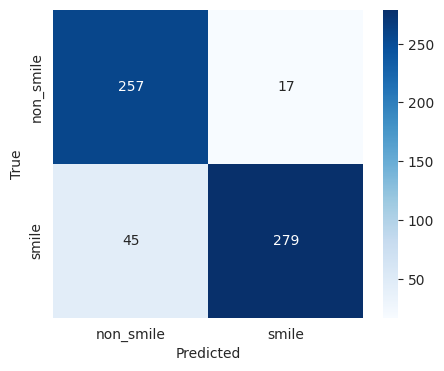

              precision    recall  f1-score   support

   non_smile       0.85      0.94      0.89       274
       smile       0.94      0.86      0.90       324

    accuracy                           0.90       598
   macro avg       0.90      0.90      0.90       598
weighted avg       0.90      0.90      0.90       598



In [19]:
y_true = []
y_pred = []

for imgs, labels in test_ds:
    preds = model.predict(imgs)
    preds = (preds > 0.5).astype(int).reshape(-1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non_smile','smile'], yticklabels=['non_smile','smile'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

print(classification_report(y_true, y_pred, target_names=['non_smile','smile']))


In [21]:
model.save("smile_detector_effnetb3.keras")

model.export("smile_detector_effnetb3_savedmodel")

print("Models saved successfully.")


INFO:tensorflow:Assets written to: smile_detector_effnetb3_savedmodel/assets


INFO:tensorflow:Assets written to: smile_detector_effnetb3_savedmodel/assets


Saved artifact at 'smile_detector_effnetb3_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name='keras_tensor_391')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140523560879696: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  140523560885456: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  140523565863696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140523565863504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140523565864272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140523565865040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140523565865616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140523565863888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140523565864080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140523565865424: TensorSpec(shape=(), dtype=

In [5]:
import cv2
import numpy as np
import tensorflow as tf
from mtcnn import MTCNN
from tensorflow.keras.applications.efficientnet import preprocess_input

detector = MTCNN()

model = tf.keras.models.load_model("smile_detector_effnetb3.keras")

IMG_SIZE = (300, 300)


In [6]:
def align_face(img, left_eye, right_eye):
    left_eye = np.array(left_eye, dtype=np.float32)
    right_eye = np.array(right_eye, dtype=np.float32)

    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]
    angle = np.degrees(np.arctan2(dy, dx))

    eye_center = (left_eye + right_eye) / 2.0
    M = cv2.getRotationMatrix2D(tuple(eye_center), angle, 1.0)
    aligned = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))

    return aligned


def detect_align_crop(img):
    detections = detector.detect_faces(img)
    if len(detections) == 0:
        return None

    det = max(detections, key=lambda d: d['box'][2] * d['box'][3])
    x, y, w, h = det['box']
    keypoints = det['keypoints']

    left_eye = keypoints['left_eye']
    right_eye = keypoints['right_eye']

    aligned = align_face(img, left_eye, right_eye)

    pad_w = int(w * 0.15)
    pad_h = int(h * 0.20)
    x1 = max(0, x - pad_w)
    y1 = max(0, y - pad_h)
    x2 = x + w + pad_w
    y2 = y + h + pad_h

    face = aligned[y1:y2, x1:x2]
    if face.size == 0:
        return None

    face = cv2.resize(face, IMG_SIZE)
    face = preprocess_input(face)
    return face


In [11]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    face = detect_align_crop(img_rgb)

    label_text = "NO FACE"

    if face is not None:
        inp = np.expand_dims(face, axis=0)
        pred = model.predict(inp)[0][0]

        if pred > 0.5:
            label_text = f"SMILE ({pred:.2f})"
            color = (0, 255, 0)
        else:
            label_text = f"NO SMILE ({pred:.2f})"
            color = (0, 0, 255)

        cv2.putText(frame, label_text, (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)
    else:
        cv2.putText(frame, label_text, (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)

    cv2.imshow("Smile Detector (EfficientNetB3 + Alignment)", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1